In [67]:
import pandas as pd
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import requests
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import stumpy
import numpy as np
from scipy.spatial.distance import cdist
import os
import random
import matplotlib.cm as cm

from distancematrix import AnytimeCalculator
from distancematrix.consumer import MatrixProfileLR
from distancematrix.generator import ZNormEuclidean
from distancematrix.generator import Euclidean
from distancematrix.insights import highest_value_idxs, lowest_value_idxs

from scipy.spatial.distance import cdist
from scipy.stats import zscore
from numpy.lib.stride_tricks import sliding_window_view
from scipy.sparse import lil_matrix, csr_matrix
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

from scipy.signal import detrend
from scipy.signal import correlate
from scipy.stats import pearsonr


In [42]:
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI    = "http://example.com/Gent-Terneuzen"
USERNAME     = "dba"
PASSWORD     = "dba"
AUTH         = (USERNAME, PASSWORD)

In [43]:
params  = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

# Identifying unique sensors


In [44]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT DISTINCT ?sensor
    WHERE {{
        GRAPH <{GRAPH_URI}> {{
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }}
    }}
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
    print(f"Error: {res.status_code}")
    print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data     = res.json()
bindings = data['results']['bindings']
for row in bindings:
    sensor_set.add(row['sensor']['value'])

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)

Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289429042', 'http://example.com/waterinfo/289441042', 'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289423042'}


# Reframe the data

In [45]:
final_df = pd.DataFrame()
print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    column_name = sensor_uri.split('/')[-1]
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{
            GRAPH <{GRAPH_URI}> {{
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }}
        }}
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']),
             'unixtime': int(row['unixtime']['value'])}
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            if final_df.empty:
                final_df = temp_df
            else:
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')
            print(f"Added column for sensor: {column_name}")

final_df = final_df.sort_values('time').set_index('time')
print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289429042
Added column for sensor: 289441042
Added column for sensor: 289435042
Added column for sensor: 289423042
Finished!
                           289429042    unixtime  289441042  289435042  \
time                                                                     
2021-03-03 23:15:00+00:00    1605.77  1614813300    4797.72    3606.54   
2021-03-03 23:30:00+00:00        NaN  1614814200    4717.80        NaN   
2021-03-03 23:45:00+00:00    1602.34  1614815100    4745.36    3556.45   
2021-03-04 00:00:00+00:00    1611.26  1614816000        NaN        NaN   
2021-03-04 00:15:00+00:00    1614.24  1614816900        NaN        NaN   

                           289423042  
time                                  
2021-03-03 23:15:00+00:00        NaN  
2021-03-03 23:30:00+00:00        NaN  
2021-03-03 23:45:00+00:00     902.27  
2021-03-04 00:00:00+00:00        NaN  
2021-03-04 00:15:00+00:00     901.96  


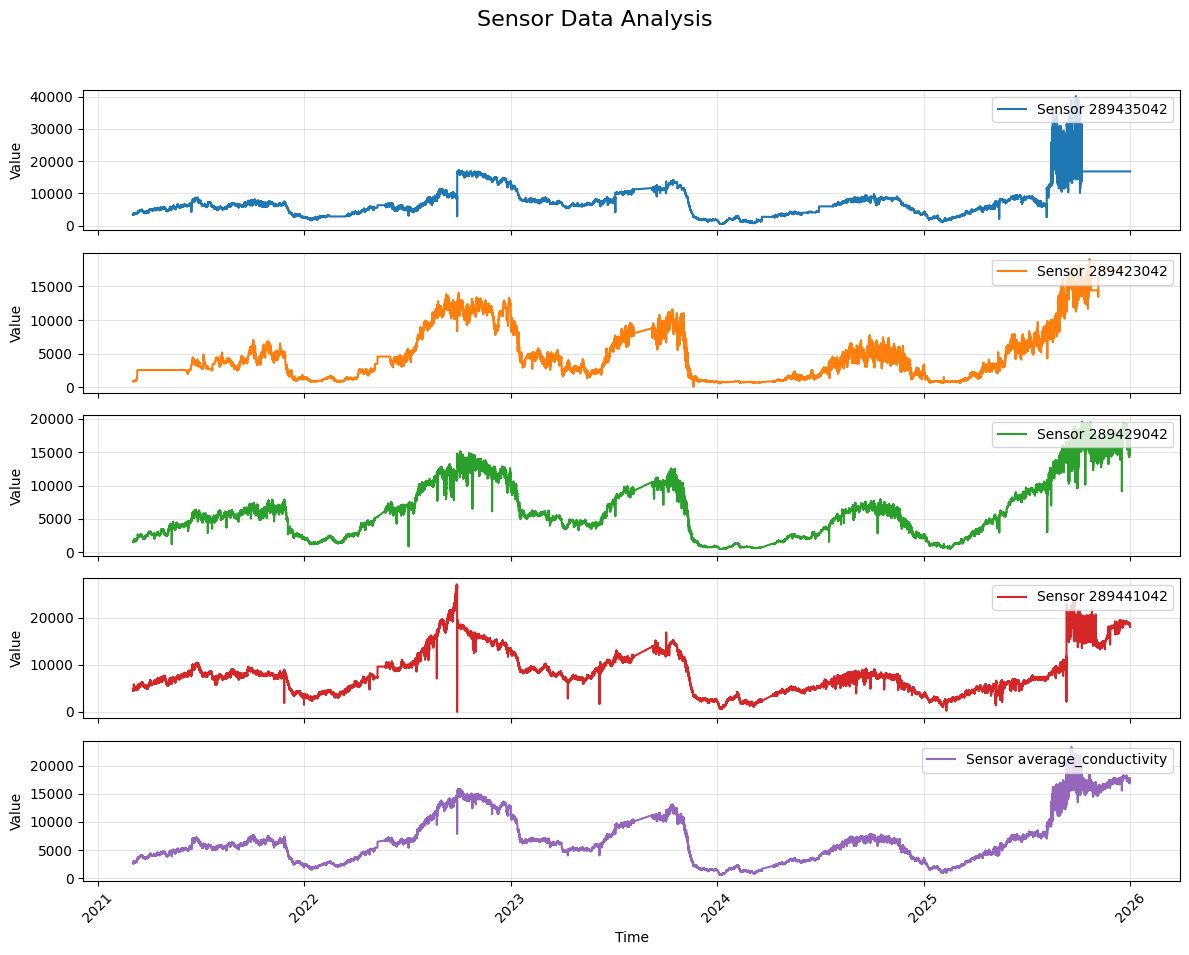

In [46]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)

sensors = ['289435042', '289423042', '289429042', '289441042']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#9467bd']
final_df = final_df.bfill().ffill()
final_df['average_conductivity'] = final_df[sensors].mean(axis=1)

sensors_with_avg = sensors + ['average_conductivity']

for i, sensor in enumerate(sensors_with_avg):
    ax = axes[i]
    ax.plot(final_df.index, final_df[sensor], label=f"Sensor {sensor}", color=colors[i])
    ax.set_ylabel("Value")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Sensor Data Analysis", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [47]:
# Resample to daily frequency and calculate the mean
daily_avg = final_df.resample('D').mean()
daily_avg = daily_avg.bfill().ffill()
daily_avg = daily_avg['average_conductivity']
print(daily_avg)

daily_avg.to_csv('daily_conductivity_averages.csv')

time
2021-03-03 00:00:00+00:00     2708.131667
2021-03-04 00:00:00+00:00     2648.320767
2021-03-05 00:00:00+00:00     2905.419382
2021-03-06 00:00:00+00:00     2939.796264
2021-03-07 00:00:00+00:00     2838.931777
                                 ...     
2025-12-27 00:00:00+00:00    17710.142005
2025-12-28 00:00:00+00:00    17709.256172
2025-12-29 00:00:00+00:00    17441.853984
2025-12-30 00:00:00+00:00    17345.273984
2025-12-31 00:00:00+00:00    17407.249297
Freq: D, Name: average_conductivity, Length: 1765, dtype: float64


# Matrix profile

In [48]:
# STUMPY doesn't handle NaNs, so we interpolate missing values
signal = final_df['average_conductivity'].interpolate(method='linear').bfill().ffill().values
# 96 periods * 15 mins = 24 hours. 8640 = 3 months (season). 2880 = 1 month
m = 96*7
# Compute the matrix profile
mp = stumpy.stump(signal, m)
#Find the Motif (most repeated pattern) and Discord (biggest anomaly)
# 1. Choose how many you want to find
top_n = 5
# Exclusion zone: once we find a motif/discord, skip 'm' points so we don't pick the same event twice
exclusion_zone = m 

# --- MULTIPLE DISCORDS (Top Peaks) ---
# We sort indices by distance in descending order (highest first)
sorted_indices = np.argsort(mp[:, 0])[::-1]
discords = []
for idx in sorted_indices:
    if len(discords) >= top_n:
        break
    # Check if this index is far enough away from already found discords
    if all(abs(idx - d) > exclusion_zone for d in discords):
        discords.append(idx)

# --- MULTIPLE MOTIFS (Lowest Valleys) ---
# We sort indices by distance in ascending order (lowest first)
sorted_indices = np.argsort(mp[:, 0])
motifs = []
for idx in sorted_indices:
    if len(motifs) >= top_n:
        break
    if all(abs(idx - m_idx) > exclusion_zone for m_idx in motifs):
        motifs.append(idx)

# Print results
print(f"Top {top_n} Discord indices:", discords)
print(f"Top {top_n} Motif indices:", motifs)

Top 5 Discord indices: [np.int64(43733), np.int64(150667), np.int64(75723), np.int64(120691), np.int64(158225)]
Top 5 Motif indices: [np.int64(92876), np.int64(25776), np.int64(96444), np.int64(88198), np.int64(24726)]


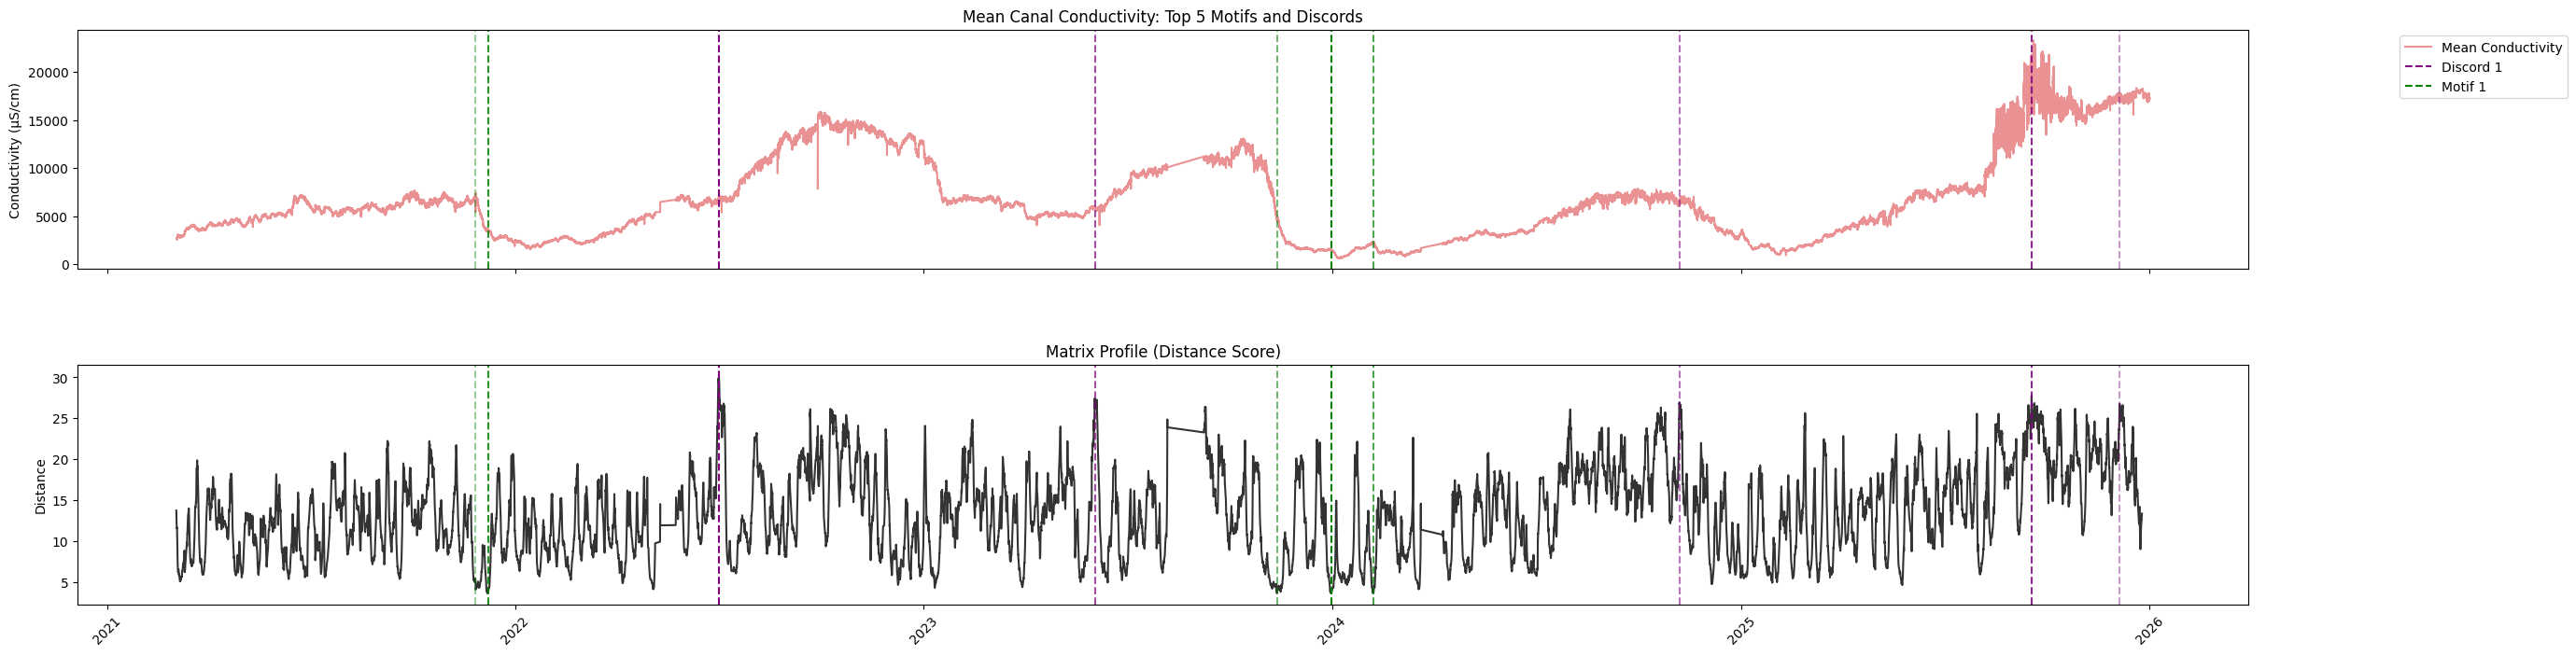

In [49]:
# Choose how many you want to display (matches the lists from the previous step)
n_to_plot = 5 

# Visualization
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0.4}, figsize=(30, 8))

# 1. TOP PLOT: Raw Signal (Average Conductivity)
axs[0].plot(final_df.index, signal, color='#d62728', alpha=0.5, label='Mean Conductivity')
axs[0].set_title(f'Mean Canal Conductivity: Top {n_to_plot} Motifs and Discords')
axs[0].set_ylabel('Conductivity (μS/cm)')

# 2. BOTTOM PLOT: Matrix Profile
axs[1].plot(final_df.index[:len(mp)], mp[:, 0], color='black', alpha=0.8)
axs[1].set_title('Matrix Profile (Distance Score)')
axs[1].set_ylabel('Distance')

# 3. LOOP TO ADD MULTIPLE LINES
# Using 'Purples' for discords and 'Greens' for motifs
for i in range(len(discords)):
    alpha_val = 1.0 - (i * 0.15) # Make the top discord darker than the others
    axs[0].axvline(x=final_df.index[discords[i]], color='purple', linestyle='--', alpha=alpha_val, label=f'Discord {i+1}' if i==0 else "")
    axs[1].axvline(x=final_df.index[discords[i]], color='purple', linestyle='--', alpha=alpha_val)

for i in range(len(motifs)):
    alpha_val = 1.0 - (i * 0.15)
    axs[0].axvline(x=final_df.index[motifs[i]], color='green', linestyle='--', alpha=alpha_val, label=f'Motif {i+1}' if i==0 else "")
    axs[1].axvline(x=final_df.index[motifs[i]], color='green', linestyle='--', alpha=alpha_val)

axs[0].legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=45)
plt.show()

# Multi dimension Matrix Profile

In [50]:
T = np.array([final_df[s].interpolate(method='linear').bfill().ffill().values for s in sensors]) #fill empty values
m = 96 * 7  # 1-week window

CACHE_FILE = "mstump_cache.npz"

if os.path.exists(CACHE_FILE):
    print("Loading cached matrix profile...")
    cache = np.load(CACHE_FILE)
    mmp   = cache["mmp"]
    mmp_I = cache["mmp_I"]
    print("Done.")
else:
    print("Computing mstump")
    mmp, mmp_I = stumpy.mstump(T, m)
    np.savez(CACHE_FILE, mmp=mmp, mmp_I=mmp_I)
    print(f"Saved to {CACHE_FILE}")


aggregate_profile = mmp[-1]  # all-dimensions combined

def find_peaks(profile, top_n, exclusion_zone, ascending=True): #Find Motifs & Discords from the 1D aggregate profile
    found = []
    for idx in np.argsort(profile)[::1 if ascending else -1]:
        if len(found) >= top_n: break
        if all(abs(idx - f) > exclusion_zone for f in found):
            found.append(int(idx))
    return found

#Find Motifs & Discords
motifs   = find_peaks(aggregate_profile, top_n=3, exclusion_zone=m, ascending=True)
discords = find_peaks(aggregate_profile, top_n=3, exclusion_zone=m, ascending=False)


Loading cached matrix profile...
Done.


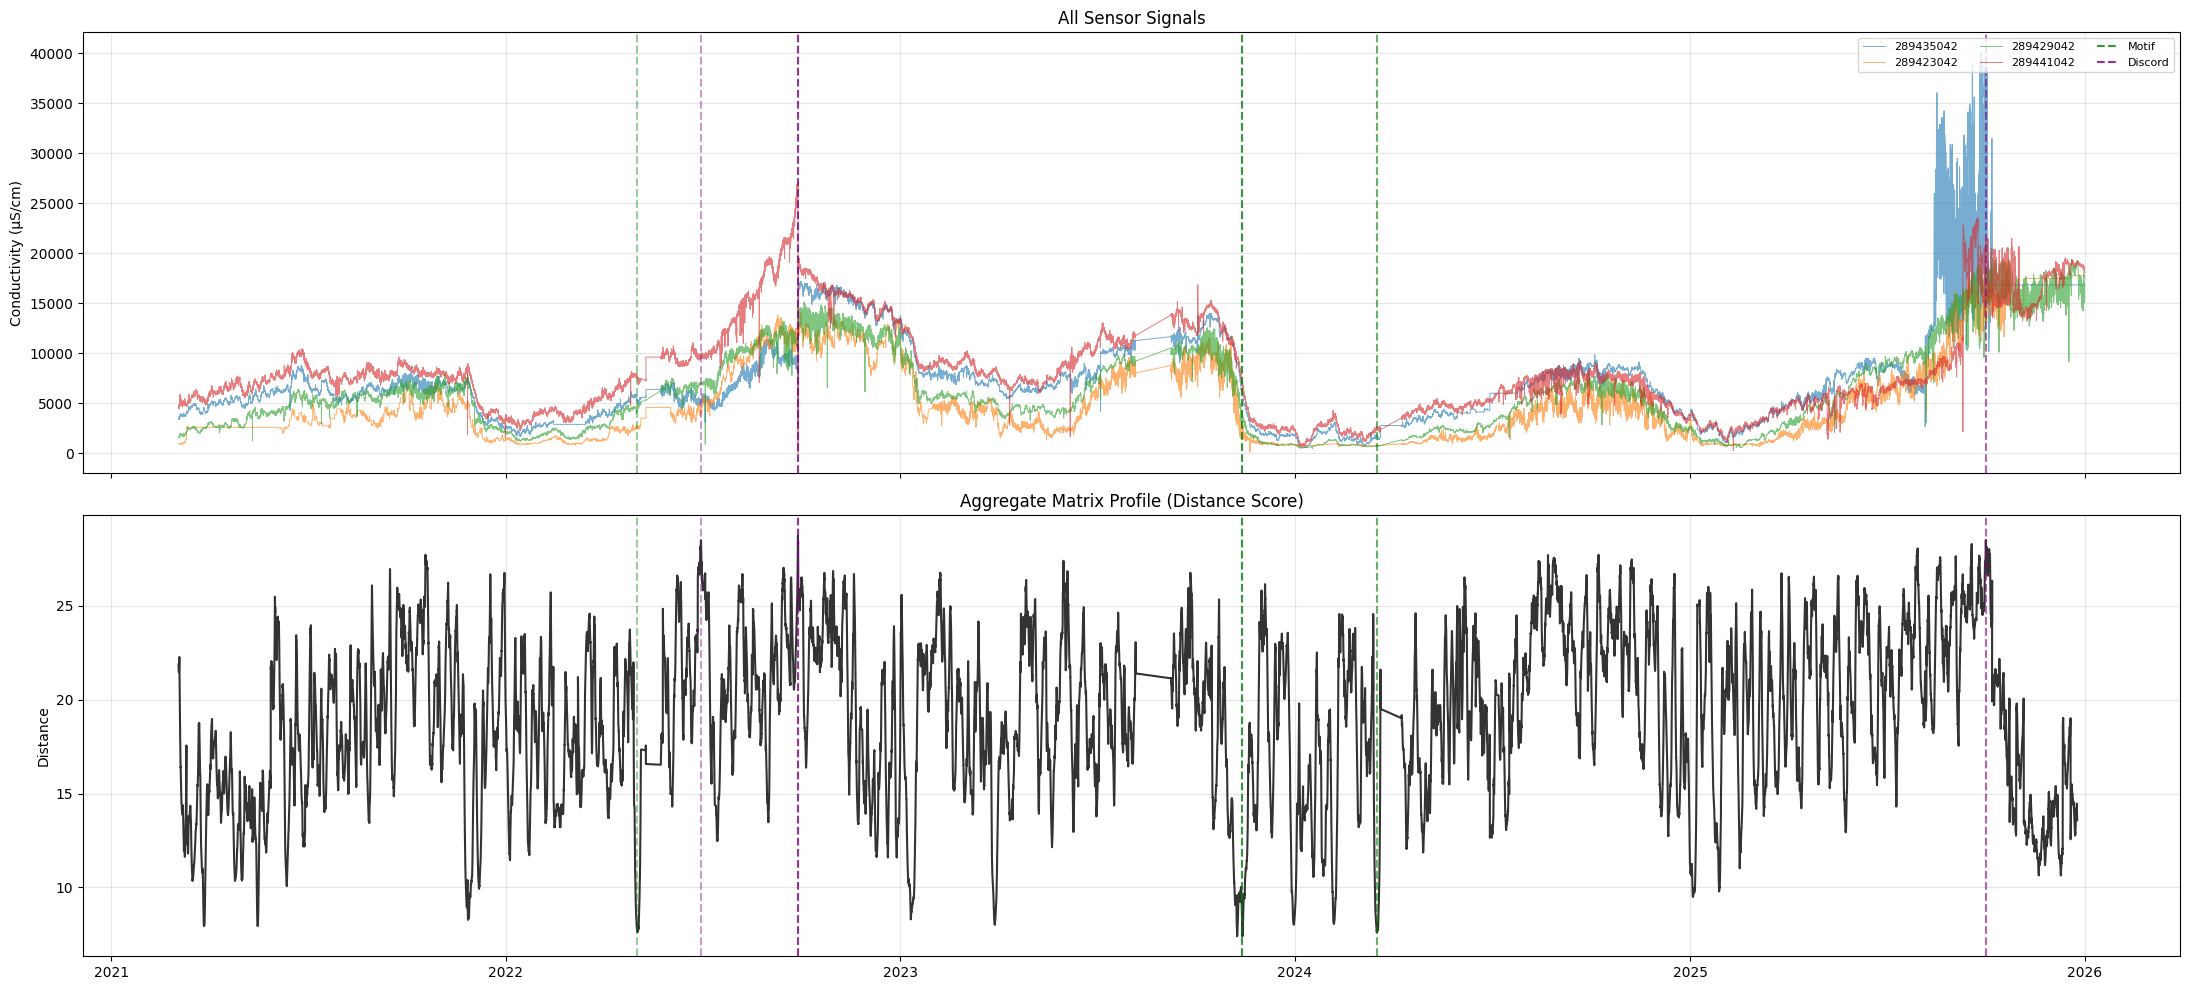

In [51]:
time_index = final_df.index
colors_sensor = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(2, 1, figsize=(22, 10), sharex=True)

# Panel A: All sensor signals
for s, col in zip(sensors, colors_sensor):
    axes[0].plot(time_index, final_df[s].interpolate().values, label=s, color=col, alpha=0.6, linewidth=0.7)
axes[0].set(title='All Sensor Signals', ylabel='Conductivity (μS/cm)')
axes[0].grid(True, alpha=0.3)

# Panel B: Aggregate matrix profile
axes[1].plot(time_index[:len(aggregate_profile)], aggregate_profile, color='black', alpha=0.8)
axes[1].set(title='Aggregate Matrix Profile (Distance Score)', ylabel='Distance')
axes[1].grid(True, alpha=0.3)

# Overlay motifs/discords on both panels
for ax in axes:
    for i, idx in enumerate(motifs):
        ax.axvline(time_index[idx], color='green',  linestyle='--', alpha=0.8 - i*0.2, label='Motif'   if (i == 0 and ax == axes[0]) else None)
    for i, idx in enumerate(discords):
        ax.axvline(time_index[idx], color='purple', linestyle='--', alpha=0.8 - i*0.2, label='Discord' if (i == 0 and ax == axes[0]) else None)

axes[0].legend(loc='upper right', fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

In [52]:
m = 96*7
resampled_df = final_df.resample('D').mean().interpolate()
ts_data = resampled_df['average_conductivity'].values
print("Calculating Contextual Matrix Profile with STUMPY...")

# 3. Create Sliding Windows
subsequences = sliding_window_view(ts_data, window_shape=m)

# 4. Calculate Distance Matrix (Now much smaller!)
print(f"Calculating matrix for {len(subsequences)} windows...")
dist_matrix = cdist(subsequences, subsequences, metric='euclidean')

# 5. Create the Diagonal Split
upper_tri = np.triu(dist_matrix)
# The image shows a darker/different contrast on the bottom
#lower_tri = np.tril(dist_matrix * 0.4) 
#combined_matrix = upper_tri + lower_tri

Calculating Contextual Matrix Profile with STUMPY...
Calculating matrix for 1094 windows...


NameError: name 'combined_matrix' is not defined

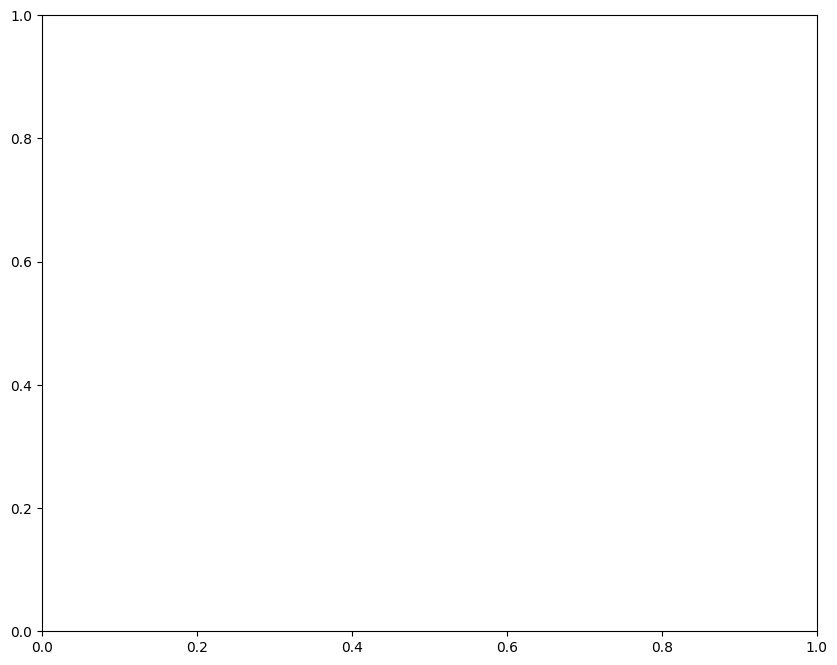

In [53]:
# 6. Plotting
fig, ax = plt.subplots(figsize=(10, 8))
n_windows = len(subsequences)

# Use 'magma' or 'viridis' for that CMP look
im = ax.imshow(combined_matrix, aspect='equal', cmap='viridis', origin='lower',
               extent=[0, n_windows, 0, n_windows])

# Add the white diagonal divider
ax.plot([0, n_windows], [0, n_windows], color='white', linewidth=0.8, alpha=0.5)

# Formatting Labels
num_ticks = 10
tick_indices = np.linspace(0, n_windows - 1, num_ticks, dtype=int)
xtick_labels = resampled_df.index[tick_indices].strftime('%Y-%m-%d')
ytick_labels = resampled_df.index[tick_indices].strftime('%Y-%m-%d')

ax.set_xticks(tick_indices)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')
ax.set_yticks(tick_indices)
ax.set_yticklabels(ytick_labels)

plt.colorbar(im, label='Euclidean Distance')
plt.title(f"Contextual Matrix Profile")
plt.tight_layout()
plt.show()

In [20]:
#####################################

In [54]:
# Resample to daily and interpolate missing values
resampled_df = final_df.resample('D').mean().interpolate()
ts_data = resampled_df['average_conductivity'].values

# ✓ FIX: after daily resampling, m=7 means 7 days (not 672 days)
m = 7

# Build sliding windows of length m
subsequences = sliding_window_view(ts_data, window_shape=m)
print(f"Subsequences shape: {subsequences.shape}")

# ✓ FIX: z-normalise each window for amplitude-invariant comparison
#        (matches what stumpy.stump does internally)
subsequences_znorm = np.array([
    zscore(s) if s.std() > 0 else s
    for s in subsequences
])

Subsequences shape: (1759, 7)


In [55]:
# Compute pairwise distance matrix on z-normed windows
dist_matrix = cdist(subsequences_znorm, subsequences_znorm, metric='euclidean')

# ✓ FIX: apply exclusion zone to avoid trivially overlapping matches
exclusion_zone = m // 2
n = len(dist_matrix)
for i in range(n):
    lo = max(0, i - exclusion_zone)
    hi = min(n, i + exclusion_zone + 1)
    dist_matrix[i, lo:hi] = np.inf

# ✓ FIX: extract the actual 1-D contextual matrix profile
#        (minimum distance to any non-excluded window)
cmp_profile = np.nanmin(
    np.where(np.isinf(dist_matrix), np.nan, dist_matrix),
    axis=1
)

# Restore symmetric view for the heatmap (replace inf → nan for display)
dist_display = np.where(np.isinf(dist_matrix), np.nan, dist_matrix)

print(f"CMP profile shape: {cmp_profile.shape}")
print(f"Profile min: {cmp_profile.min():.4f}, max: {cmp_profile.max():.4f}")

CMP profile shape: (1759,)
Profile min: 0.0000, max: 1.7333


In [56]:
def find_peaks(profile, top_n, exclusion_zone, ascending=True):
    """Find non-overlapping motifs (ascending=True) or discords (False)."""
    found = []
    for idx in np.argsort(profile)[:: 1 if ascending else -1]:
        if np.isnan(profile[idx]) or np.isinf(profile[idx]):
            continue
        if len(found) >= top_n:
            break
        if all(abs(idx - f) > exclusion_zone for f in found):
            found.append(int(idx))
    return found

motifs   = find_peaks(cmp_profile, top_n=3, exclusion_zone=m, ascending=True)
discords = find_peaks(cmp_profile, top_n=3, exclusion_zone=m, ascending=False)

time_index = resampled_df.index
print("Motif dates:  ", [str(time_index[i].date()) for i in motifs])
print("Discord dates:", [str(time_index[i].date()) for i in discords])

Motif dates:   ['2024-03-28', '2023-08-19', '2023-08-11']
Discord dates: ['2025-09-21', '2022-10-24', '2025-10-11']


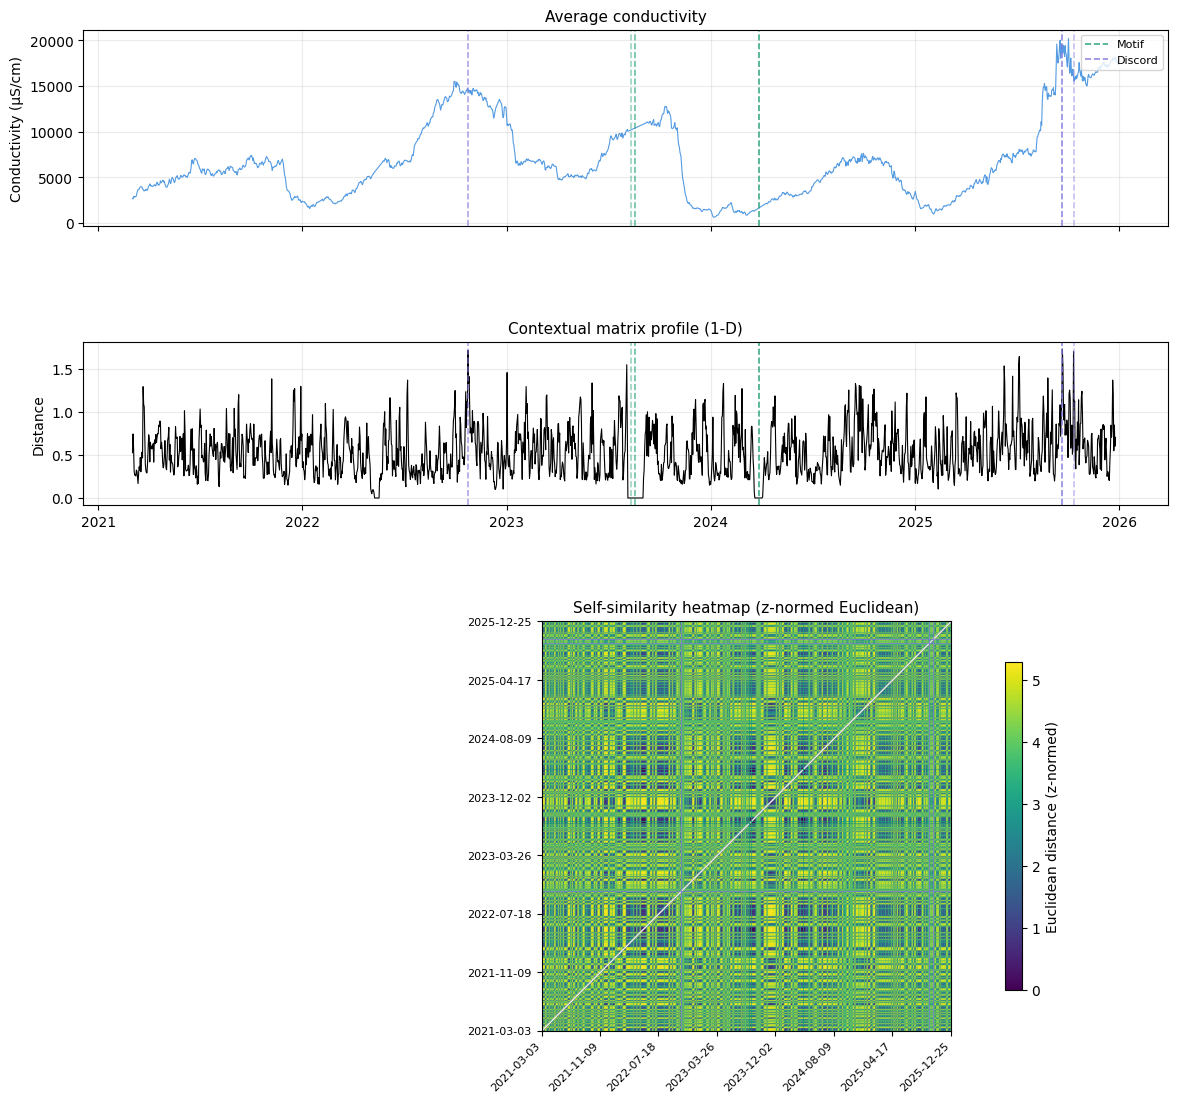

In [57]:
fig = plt.figure(figsize=(14, 13))
gs  = fig.add_gridspec(3, 1, height_ratios=[1.2, 1, 2.5], hspace=0.45)

ax_sig  = fig.add_subplot(gs[0])
ax_cmp  = fig.add_subplot(gs[1], sharex=ax_sig)
ax_heat = fig.add_subplot(gs[2])

profile_index = time_index[: len(cmp_profile)]

# ── Panel A: raw signal ──────────────────────────────────────────────────────
ax_sig.plot(time_index, ts_data, color='#378ADD', linewidth=0.8, alpha=0.85)
ax_sig.set_ylabel('Conductivity (μS/cm)')
ax_sig.set_title('Average conductivity', fontsize=11)
ax_sig.grid(True, alpha=0.25)


# ── Panel B: 1-D contextual matrix profile ───────────────────────────────────
ax_cmp.plot(profile_index, cmp_profile, color='black', linewidth=0.8)
ax_cmp.set_ylabel('Distance')
ax_cmp.set_title('Contextual matrix profile (1-D)', fontsize=11)
ax_cmp.grid(True, alpha=0.25)

# Overlay motifs & discords on both signal panels
for ax in [ax_sig, ax_cmp]:
    for i, idx in enumerate(motifs):
        ax.axvline(time_index[idx], color='#1D9E75', linestyle='--',
                   linewidth=1.2, alpha=0.85 - i * 0.2,
                   label='Motif' if (i == 0 and ax == ax_sig) else None)
    for i, idx in enumerate(discords):
        ax.axvline(time_index[idx], color='#7F77DD', linestyle='--',
                   linewidth=1.2, alpha=0.85 - i * 0.2,
                   label='Discord' if (i == 0 and ax == ax_sig) else None)

ax_sig.legend(loc='upper right', fontsize=8)
ax_sig.tick_params(labelbottom=False)

# ── Panel C: self-similarity heatmap ─────────────────────────────────────────
# ✓ FIX: raw distances only, no lower-tri scaling — colorbar is truthful
im = ax_heat.imshow(
    dist_display, aspect='equal', cmap='viridis', origin='lower',
    extent=[0, n, 0, n]
)
ax_heat.plot([0, n], [0, n], color='white', linewidth=0.7, alpha=0.5)

# ✓ FIX: mark motifs/discords on the heatmap as crosshairs
for idx in motifs:
    ax_heat.axvline(idx, color='#1D9E75', linewidth=0.8, alpha=0.7)
    ax_heat.axhline(idx, color='#1D9E75', linewidth=0.8, alpha=0.7)
for idx in discords:
    ax_heat.axvline(idx, color='#7F77DD', linewidth=0.8, alpha=0.7)
    ax_heat.axhline(idx, color='#7F77DD', linewidth=0.8, alpha=0.7)

num_ticks   = 8
tick_indices = np.linspace(0, n - 1, num_ticks, dtype=int)
tick_labels  = resampled_df.index[tick_indices].strftime('%Y-%m-%d')
ax_heat.set_xticks(tick_indices); ax_heat.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
ax_heat.set_yticks(tick_indices); ax_heat.set_yticklabels(tick_labels, fontsize=8)
ax_heat.set_title('Self-similarity heatmap (z-normed Euclidean)', fontsize=11)

plt.colorbar(im, ax=ax_heat, label='Euclidean distance (z-normed)', shrink=0.8)
plt.savefig('cmp_output.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
# To Do: make a heat map per year 

# Rain Data

In [62]:

# 1. Load the data
rain_data = pd.read_csv('../data/ertveldeprecipitation.csv', sep=';')
rain_data['Value'] = pd.to_numeric(rain_data['Value'].astype(str).str.replace(',', '.'), errors='coerce')
# 2. CONVERT timestamp to actual datetime objects (Crucial Step!)
rain_data['timestamp'] = pd.to_datetime(rain_data['timestamp'], utc=True)
# 3. Sort and set the index
rain_data = rain_data.sort_values('timestamp').set_index('timestamp')
# 4. Now resample will work perfectly
daily_rain = rain_data['Value'].resample('D').sum().bfill().ffill()
print(rain_data.head())
print(rain_data.columns.tolist())

C:\Users\AYMANS\AppData\Local\Temp\ipykernel_29932\3920007657.py:2: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  rain_data = pd.read_csv('../data/ertveldeprecipitation.csv', sep=';')


                           Value  Quality Code  Absolute Value  \
timestamp                                                        
2021-03-02 23:00:00+00:00    0.0           130             NaN   
2021-03-02 23:15:00+00:00    0.0           130             NaN   
2021-03-02 23:30:00+00:00    0.0           130             NaN   
2021-03-02 23:45:00+00:00    0.0           130             NaN   
2021-03-03 00:00:00+00:00    0.0           130             NaN   

                           AV Quality Code           #station_name  Ertvelde_P  
timestamp                                                                       
2021-03-02 23:00:00+00:00              NaN             #station_no     P03_041  
2021-03-02 23:15:00+00:00              NaN  #stationparameter_name           N  
2021-03-02 23:30:00+00:00              NaN     #parametertype_name           N  
2021-03-02 23:45:00+00:00              NaN                #ts_name        P.15  
2021-03-03 00:00:00+00:00              NaN         

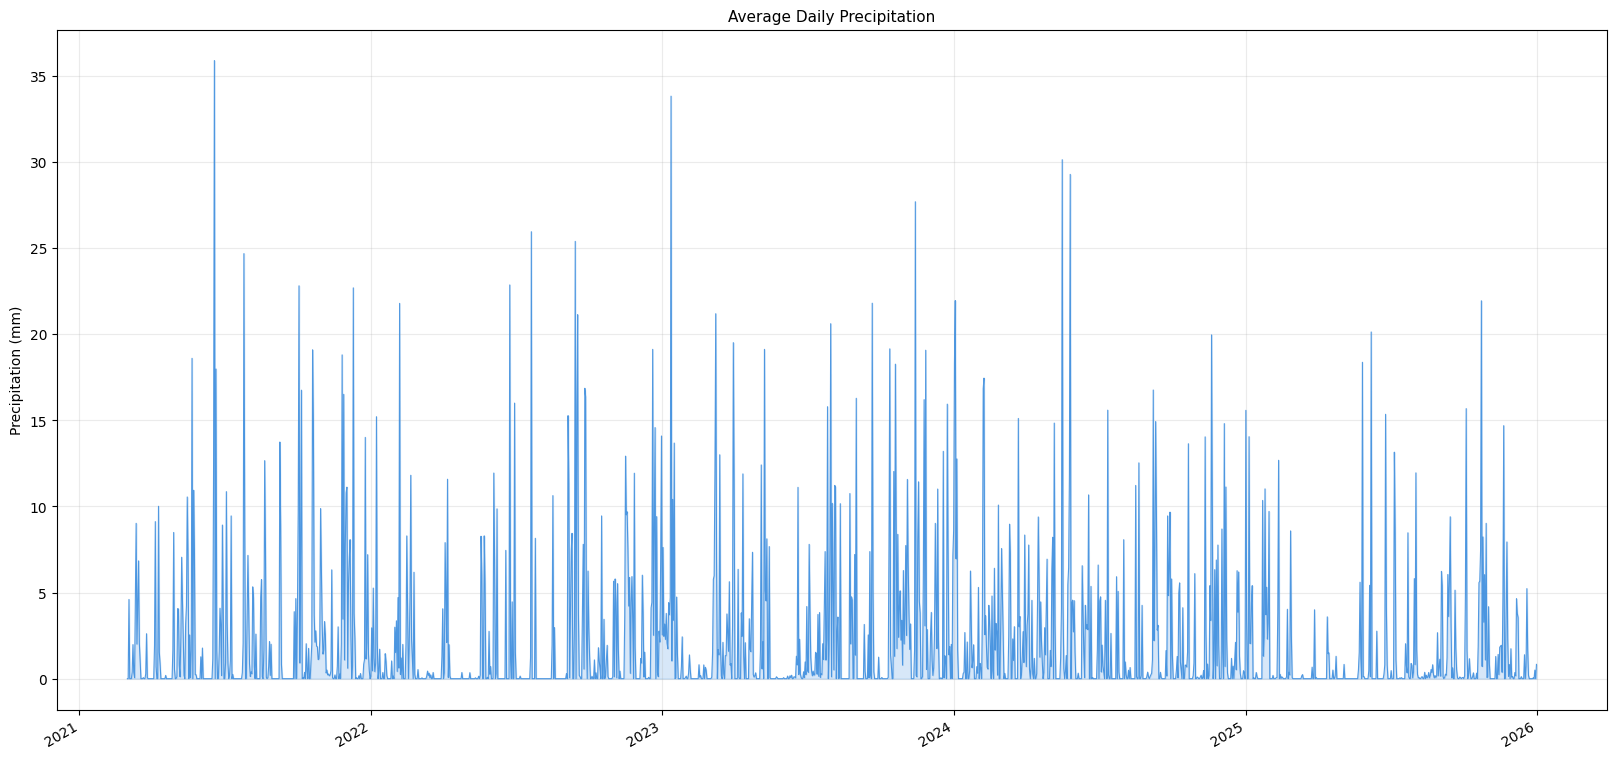

In [63]:
# 1. Setup the figure
# We use nrows=1 to match the single plot, removing height_ratios
fig = plt.figure(figsize=(20, 10))
gs  = fig.add_gridspec(1, 1)
ax_sig = fig.add_subplot(gs[0])

# 2. Plotting
# We use daily_rain.index for the x-axis and daily_rain.values for the y-axis
ax_sig.plot(daily_rain.index, daily_rain.values, 
            color='#378ADD', 
            linewidth=0.8, 
            alpha=0.85, 
            label='Daily Average')

# 3. Aesthetics
ax_sig.set_ylabel('Precipitation (mm)')
ax_sig.set_title('Average Daily Precipitation', fontsize=11)
ax_sig.grid(True, alpha=0.25)

# 4. Optional: Area fill for better "rain" look
ax_sig.fill_between(daily_rain.index, daily_rain.values, color='#378ADD', alpha=0.2)

# Tilt dates for readability
fig.autofmt_xdate()

plt.show()

To Do: 

1- visual overlay
2- Cross-correlation
3- Joint Matrix profile

# Rain Conductivity Overlay

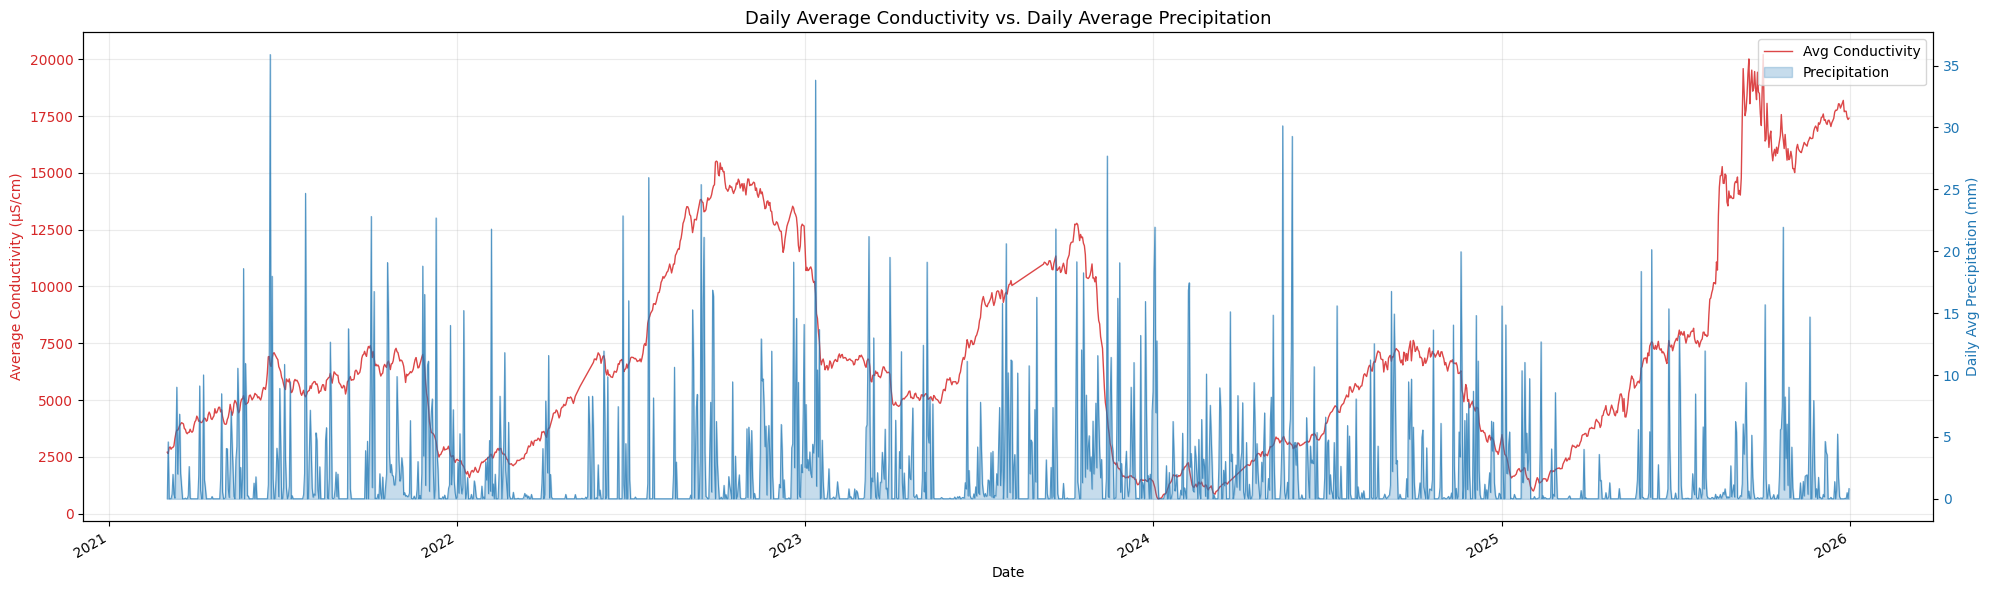

In [64]:
# ── Overlay: Daily Average Precipitation vs Daily Average Conductivity ────────

# Align the two series on a common date range
common_start = max(daily_rain.index.min(), resampled_df.index.min())
common_end   = min(daily_rain.index.max(), resampled_df.index.max())

rain_aligned = daily_rain.loc[common_start:common_end]
cond_aligned = resampled_df.loc[common_start:common_end, 'average_conductivity']

fig, ax1 = plt.subplots(figsize=(20, 6))

# ── Left axis: Conductivity ───────────────────────────────────────────────────
color_cond = '#d62728'
ax1.set_ylabel('Average Conductivity (μS/cm)', color=color_cond)
ax1.plot(cond_aligned.index, cond_aligned.values,
         color=color_cond, linewidth=1.0, alpha=0.85, label='Avg Conductivity')
ax1.tick_params(axis='y', labelcolor=color_cond)
ax1.set_xlabel('Date')

# ── Right axis: Precipitation ─────────────────────────────────────────────────
color_rain = '#1f77b4'
ax2 = ax1.twinx()
ax2.set_ylabel('Daily Avg Precipitation (mm)', color=color_rain)
ax2.fill_between(rain_aligned.index, rain_aligned.values,
                  color=color_rain, alpha=0.25, label='Precipitation')
ax2.plot(rain_aligned.index, rain_aligned.values,
         color=color_rain, linewidth=0.8, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color_rain)

# ── Legend & formatting ───────────────────────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Daily Average Conductivity vs. Daily Average Precipitation', fontsize=13)
ax1.grid(True, alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('conductivity_vs_precipitation.png', dpi=150, bbox_inches='tight')
plt.show()


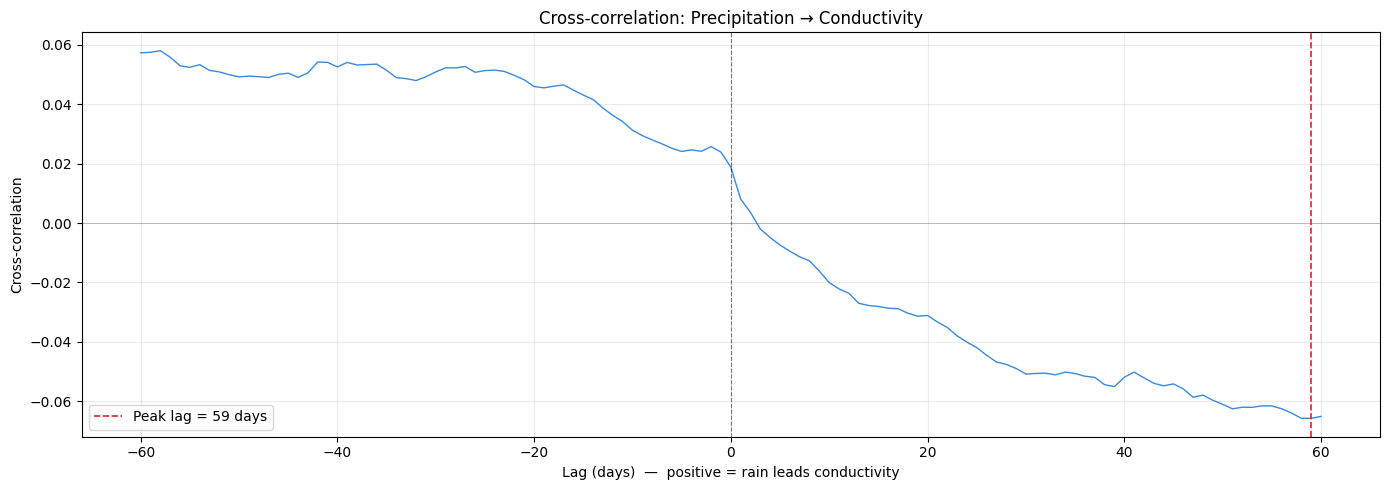

Peak correlation -0.066 at lag 59 days


In [66]:
# ── 1. Align and clean ────────────────────────────────────────────────────────
common_start = max(daily_rain.index.min(), resampled_df.index.min())
common_end   = min(daily_rain.index.max(), resampled_df.index.max())

rain = daily_rain.loc[common_start:common_end].values
cond = resampled_df.loc[common_start:common_end, 'average_conductivity'].values

# Z-normalise both so the result is a true correlation (-1 to 1)
rain_z = (rain - rain.mean()) / rain.std()
cond_z = (cond - cond.mean()) / cond.std()

# ── 2. Compute cross-correlation ──────────────────────────────────────────────
n    = len(rain_z)
xcorr = correlate(cond_z, rain_z, mode='full') / n
lags  = np.arange(-(n - 1), n)  # lag in days

# Focus on a meaningful window (e.g. ±60 days)
window = 60
mask   = (lags >= -window) & (lags <= window)

# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lags[mask], xcorr[mask], color='#378ADD', linewidth=1.0)
ax.axvline(0,  color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(0,  color='black', linewidth=0.5, alpha=0.3)

# Mark the peak lag
peak_lag = lags[mask][np.argmax(np.abs(xcorr[mask]))]
ax.axvline(peak_lag, color='#d62728', linewidth=1.2, linestyle='--',
           label=f'Peak lag = {peak_lag} days')

ax.set_xlabel('Lag (days)  —  positive = rain leads conductivity')
ax.set_ylabel('Cross-correlation')
ax.set_title('Cross-correlation: Precipitation → Conductivity')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('cross_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak correlation {xcorr[mask][np.argmax(np.abs(xcorr[mask]))]:.3f} at lag {peak_lag} days")